In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)  # show all 11 columns, never truncate
sns.set_theme(style="whitegrid")

# The notebook runs from notebooks/, so the data is one level up.
DATA_PATH = "../data/raw/paysim.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 6,362,620 rows × 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
# Q1: What is the fraud rate?
fraud_counts = df["isFraud"].value_counts()
fraud_rate = df["isFraud"].mean()

print("Class distribution (isFraud):")
print(fraud_counts.to_string())
print(f"\nFraud:       {fraud_counts.get(1, 0):>10,}")
print(f"Legitimate:  {fraud_counts.get(0, 0):>10,}")
print(f"\nFraud rate:  {fraud_rate:.4%}")
print(f"Imbalance:   1 fraud per {round(1 / fraud_rate):,} transactions")

Class distribution (isFraud):
isFraud
0    6354407
1       8213

Fraud:            8,213
Legitimate:   6,354,407

Fraud rate:  0.1291%
Imbalance:   1 fraud per 775 transactions


In [3]:
# Q2: Which transaction types contain fraud?
type_fraud = df.groupby("type")["isFraud"].agg(
    total="count",
    fraud="sum",
)
type_fraud["fraud_rate"] = type_fraud["fraud"] / type_fraud["total"]
type_fraud = type_fraud.sort_values("fraud", ascending=False)

print(
    type_fraud.to_string(
        formatters={
            "total": "{:,}".format,
            "fraud": "{:,}".format,
            "fraud_rate": "{:.4%}".format,
        }
    )
)

             total fraud fraud_rate
type                               
CASH_OUT 2,237,500 4,116    0.1840%
TRANSFER   532,909 4,097    0.7688%
CASH_IN  1,399,284     0    0.0000%
DEBIT       41,432     0    0.0000%
PAYMENT  2,151,495     0    0.0000%


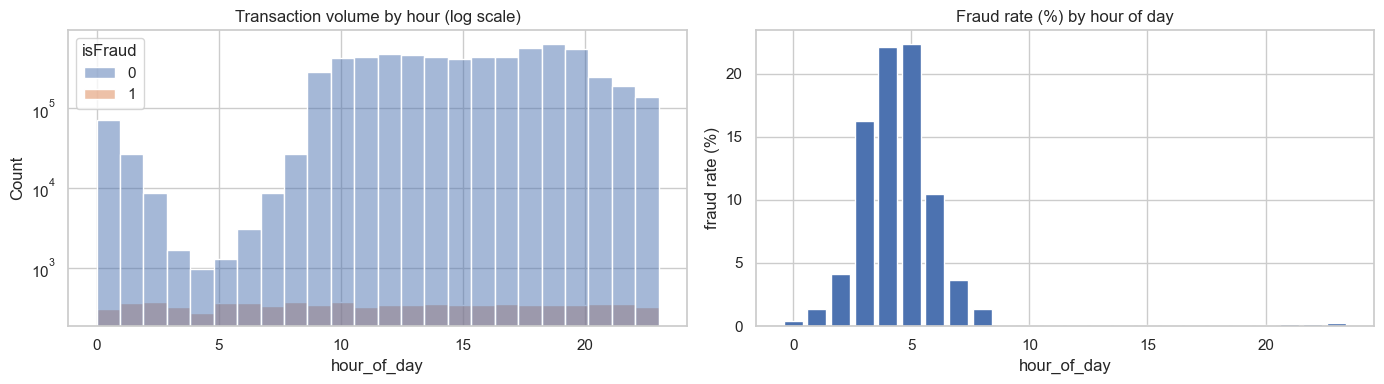

,total,fraud,fraud_rate,fraud_rate_pct
hour_of_day,,,,
0,71587,300,0.004191,0.419
1,27111,358,0.013205,1.320
2,9018,372,0.041251,4.125
3,2007,326,0.162431,16.243
4,1241,274,0.220790,22.079
5,1641,366,0.223035,22.303
6,3420,358,0.104678,10.468
7,8988,328,0.036493,3.649
8,26915,368,0.013673,1.367


In [4]:
# Q3: Do frauds follow time-of-day patterns?
df["hour_of_day"] = df["step"] % 24

hourly = df.groupby("hour_of_day")["isFraud"].agg(total="count", fraud="sum")
hourly["fraud_rate"] = hourly["fraud"] / hourly["total"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: transaction VOLUME by hour, split by class (log scale)
sns.histplot(
    data=df, x="hour_of_day", hue="isFraud", bins=24,
    multiple="layer", stat="count", ax=axes[0],
)
axes[0].set_yscale("log")  # legit volume dwarfs fraud; log lets us see both
axes[0].set_title("Transaction volume by hour (log scale)")

# Right: fraud RATE by hour
axes[1].bar(hourly.index, hourly["fraud_rate"] * 100)
axes[1].set_title("Fraud rate (%) by hour of day")
axes[1].set_xlabel("hour_of_day")
axes[1].set_ylabel("fraud rate (%)")

plt.tight_layout()
plt.show()

hourly.assign(fraud_rate_pct=(hourly["fraud_rate"] * 100).round(3))

             count          mean           std   min         25%        50%         75%          max
isFraud                                                                                             
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   208364.76  92445516.64
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44  1517771.48  10000000.00


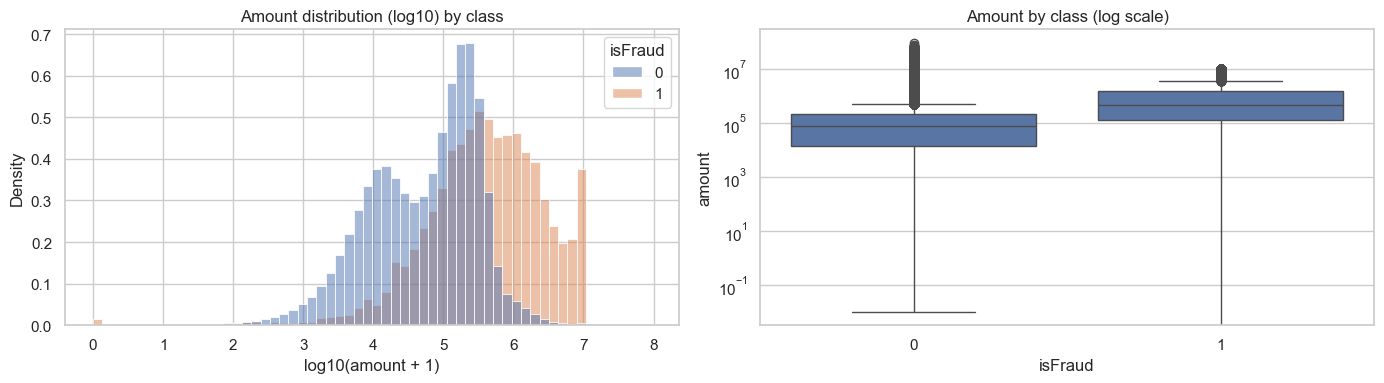

In [5]:
# Q4: How do transaction amounts differ, fraud vs legitimate?
print(df.groupby("isFraud")["amount"].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: log-amount distribution, each class normalized separately
sns.histplot(
    data=df.assign(log_amount=np.log10(df["amount"] + 1)),
    x="log_amount", hue="isFraud", bins=60,
    multiple="layer", stat="density", common_norm=False, ax=axes[0],
)
axes[0].set_title("Amount distribution (log10) by class")
axes[0].set_xlabel("log10(amount + 1)")

# Right: amount boxplot by class, log y-axis
sns.boxplot(data=df, x="isFraud", y="amount", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Amount by class (log scale)")

plt.tight_layout()
plt.show()

In [6]:
# Q5: Are there null values? Any duplicate rows?
print("Null counts per column:")
print(df.isnull().sum().to_string())

print(f"\nFully-duplicated rows: {df.duplicated().sum():,}")

# The brief treats (step, nameOrig, nameDest, amount) as a natural key
key_cols = ["step", "nameOrig", "nameDest", "amount"]
print(f"Duplicates on {key_cols}: {df.duplicated(subset=key_cols).sum():,}")

Null counts per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
hour_of_day       0

Fully-duplicated rows: 0
Duplicates on ['step', 'nameOrig', 'nameDest', 'amount']: 0


In [7]:
# Q6 setup: do customers repeat? Window aggregates only matter if they do.
orig_freq = df["nameOrig"].value_counts()

print("Transactions per originating customer:")
print(orig_freq.describe().to_string())

print("\nHow many customers appear exactly N times:")
print(orig_freq.value_counts().sort_index().head(8).to_string())

Transactions per originating customer:
count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00

How many customers appear exactly N times:
count
1    6344009
2       9283
3         15


In [ ]:
# Do DESTINATION accounts repeat? (fraud mules receive multiple transfers)
dest_freq = df["nameDest"].value_counts()
print("Transactions per destination account:")
print(dest_freq.describe().to_string())
print(f"Destinations seen > 1 time: {(dest_freq > 1).sum():,}")

# The strongest known PaySim signal: balance inconsistencies.
# A consistent transfer should reconcile: newOrig = oldOrig - amount, newDest = oldDest + amount.
df["errorBalanceOrig"] = df["newbalanceOrig"] + df["amount"] - df["oldbalanceOrg"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

print("\nMean |errorBalanceOrig| by class:")
print(df.groupby("isFraud")["errorBalanceOrig"].apply(lambda s: s.abs().mean()).to_string())
print("\nMean |errorBalanceDest| by class:")
print(df.groupby("isFraud")["errorBalanceDest"].apply(lambda s: s.abs().mean()).to_string())

### Q6: Transaction-time features vs. history-dependent features

**Available at transaction time** (computable from the single incoming row — no leakage risk):
`amount`, `type`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`,
`hour_of_day` (step % 24), `balance_delta`, `amount_to_balance_ratio`, `is_round_amount`,
`errorBalanceOrig`, `errorBalanceDest`.

**Require historical aggregation** (must look at prior transactions of the same entity):
`tx_count_1h/24h/7d`, `tx_amount_sum_24h`, `tx_amount_avg_24h`.

**Temporal leakage:** if these aggregates are computed over the *entire* dataset, each
training row sees transactions that occurred *after* it — information unavailable in
production. The model learns from the future and looks great offline, then fails live.
The fix is **point-in-time-correct joins**: each row may only use data with a timestamp
*before* its own. This is the entire reason the project uses a feature store (Feast) — it
guarantees point-in-time correctness automatically.

**PaySim caveat:** 99.85% of originating customers appear only once, so per-customer
window aggregates are near-empty and weakly predictive. The dominant signal is row-level
balance-consistency (`errorBalanceOrig/Dest`) and `amount`/`hour_of_day`. Window features
are retained mainly to demonstrate the Spark + feature-store engineering, and are better
keyed on the destination account (mules repeat).